In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [1]:

# Define variables
x, y = sp.symbols('x y', real=True)
z_sym = sp.symbols('z')  # Use a symbol for differentiation
mu, tau = sp.symbols('mu tau', positive=True) # Rigidity and twist

In [2]:
# Example: Torsion of an Ellipse
# Complex Torsion Function F(z) approx i*A*z^2 (for ellipse)
# Let's verify the stresses
A = sp.symbols('A')
F_z_symbolic = sp.I * A * z_sym**2

# In Muskhelishvili Ch 22, stress components depend on F'(z)
# X_z - i Y_z = mu * tau * (F'(z) - i*z_conjugate)
# (See formula 132.6 in the text)

# First, differentiate F with respect to the *symbol* z
dF_dz_symbolic = sp.diff(F_z_symbolic, z_sym)

In [3]:
# Now, substitute the symbol z with the coordinate expression x + I*y
z = x + sp.I*y
dF_dz = dF_dz_symbolic.subs(z_sym, z)
z_conj = x - sp.I*y

# Complex Stress Vector
Stress_Complex = mu * tau * (dF_dz - sp.I * z_conj)

# Extract components
X_z = sp.re(Stress_Complex)
Y_z = -sp.im(Stress_Complex) # Note the sign convention in the book

print(f"Stress X_z: {sp.simplify(X_z)}")
print(f"Stress Y_z: {sp.simplify(Y_z)}")

Stress X_z: -mu*tau*(2*x*im(A) + 2*y*re(A) + y)
Stress Y_z: mu*tau*(-2*x*re(A) + x + 2*y*im(A))


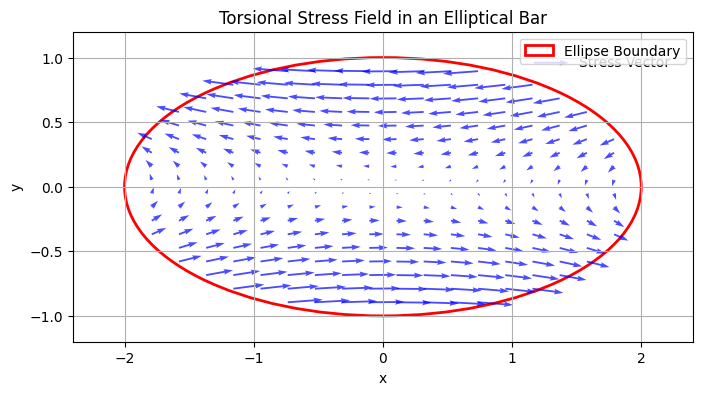

In [4]:

# --- Plotting ---

# Define ellipse parameters
a = 2.0  # semi-major axis
b = 1.0  # semi-minor axis

# For an ellipse, the constant A is related to the geometry
A_val = (a**2 - b**2) / (a**2 + b**2)

# Lambdify the stress expressions for numerical evaluation
# We'll set mu and tau to 1 for simplicity in the plot
X_z_func = sp.lambdify((x, y), X_z.subs({A: A_val, mu: 1, tau: 1}), 'numpy')
Y_z_func = sp.lambdify((x, y), Y_z.subs({A: A_val, mu: 1, tau: 1}), 'numpy')

# Create a grid of points
x_vals = np.linspace(-a, a, 20)
y_vals = np.linspace(-b, b, 20)
X, Y = np.meshgrid(x_vals, y_vals)

# Calculate stresses on the grid
U = X_z_func(X, Y)
V = Y_z_func(X, Y)

# Mask out points outside the ellipse
ellipse_mask = (X**2 / a**2 + Y**2 / b**2) > 1
U[ellipse_mask] = np.nan
V[ellipse_mask] = np.nan

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
ellipse_patch = Ellipse(xy=(0, 0), width=2*a, height=2*b,
                        edgecolor='r', fc='None', lw=2, label='Ellipse Boundary')
ax.add_patch(ellipse_patch)

# Plot the stress field
quiver = ax.quiver(X, Y, U, V, color='b', alpha=0.7)
ax.quiverkey(quiver, X=0.8, Y=0.9, U=np.nanmax(U),
             label='Stress Vector', labelpos='E')

# Set plot limits and labels
ax.set_xlim(-a * 1.2, a * 1.2)
ax.set_ylim(-b * 1.2, b * 1.2)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Torsional Stress Field in an Elliptical Bar')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True)
plt.show()
